06. 임베딩

- 앞서 입력된 문장을 컴퓨터가 이해할 수 있는 단위인 토큰으로 나누는 토큰화 과정에 대해 알아봄, 그러나 토큰화만으로는 모델으 학습할 수 없음, 컴퓨터는 텍스트 자체를 이해할 수 없으므로 텍스트를 숫자로 변환하는 텍스트 벡터화(Text Vectorization) 과정이 필요
- 텍스트 벡터화란 텍스트를 숫자로 변환하는 과정을 의미함, 기초적인 텍스트 벡터화로는 원-핫 인코딩(One-Hot Encoding), 빈도 벡터화(Count Vectorization) 등이 있음
- 먼저 원-핫 인코딩이란 문서에 등장하는 각 단어를 고유한 색인 값으러 매핑한 후, 해당 색인 위치를 1로 표시하고 너머지 위치는 모두 0으로 표시하는 방식
- 예를 들어, "I like apples" 문장과 "I like bananas" 문장을 띄어쓰기 기준으로 토큰화하고 단어를 고유한 색인 값으로 매핑하면 아래 그림의 표와 같음
- 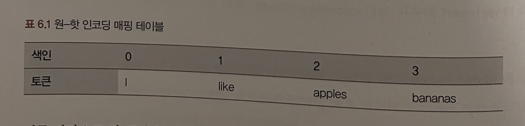
- 이를 바탕으로 각 문장을 원-핫 인코딩한다면 "I like apples" 문장과 "I like bananas" 문장은 아래와 같이 표현
    - I like apples: [1, 1, 1, 0]
    - I like bananas: [1, 1, 0, 1]

- 빈도 벡터화는 문서에서 단어의 빈도수를 세어 해당 단어의 빈도를 벡터로 표현하는 방식, 예를 들어 apples 라는 단어가 총 4번 등장한다면, 해단 단어의 벡터값은 4가 된다.
- 원-핫 인코딩 방식은 같은 단어가 어러번 등장하더라고 1과 0으로 표현하지만, 빈도벡터화는 해당 단어의 빈도로 표시한다.
- 이러한 방식은 단어나 문장을 벡터 형태로 변환하기 쉽고 간당하다는 장점이 있지만, 벡터의 희소성(Sparsity)이 크다는 단점이 있음
- 말뭉치 내에 존재하는 토큰의 개수만큼의 벡터 차원을 가져야 하지만, 입력 문장 내에 존재하는 토큰의 수는 그에 비해 현저히 적기 때문에 컴퓨팅 비용의 증가와 차원의 저주와 같은 문제를 겪을 수 있음, 또한 텍스트의 벡터가 입력 텍스트의 의미를 내포하고 있지 않으므로 두 문장이 의미적으로 유사하다고 해도 벡터가 유사하지 않을 수 있음, 예를 들어 "i scream for ice cream" 과 "ice cream for i scream" 에 원-핫 인코딩이나 빈도 벡터화를 적용하면 둘다 [1, 1, 1, 1, 1] 벡터로 변환, 이러한 문제를 해결하기 위해 워드 투 벡터(Word2Vec)나 패스트 텍스트(fastText) 등과 같이 단어의 의미를 학습해 표현하는 워드 임베딩(Word Embedding) 기법을 사용
- 워드 임베딩 기법은 단어를 고정된 길이의 실수 벡터로 표현하는 방법, 단어의 의미를 벡터 공간에서 다른 단어와의 상태적 위치로 표현해 단어 간의 관계를 추론
- 워드 임베딩은 고정된 임베딩을 학습하기 때문에 다의어나 문맥 정보를 다루기 어렵다는 단점이 있어 인공 신경망을 활용해 동적 임베징(Dynamic Embedding) 기법을 사용

언어 모델

- 언어 모델(Language Model)이란 입련된 문장으로 각 문장을 생설할 수 있는 확률을 계산하는 모델을 의미, 이를 위해 주어진 문장을 바탕으로 문맥을 이해하고, 문장 구성에 대한 예측을 수행
- 언어 모델은 자동 번역, 음성 인식, 텍스트 요약 등 다양한 자연어 처리 분야에서 활용, 아래 그림은 언어 모델 구조를 간략히 표현
- 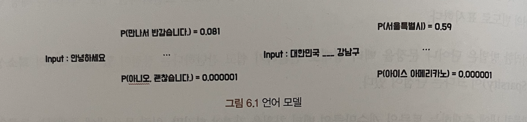
- "안녕하세요" 라는 문장 뒤에 어떤 문장이 어떤 확률로 등장할지 계산하는 것은 어려움, 이는 비지도 학습 문제로 모델 스스로 문장 등장 확률을 계산해야 함, 또한 "안녕하세요" 다음에 올 수 있는 문장은 사실상 무한에 가까움, 그러므로 완성된 문장 단위로 확률을 계산하는 것은 불가능
- 주어진 문장 뒤에 나올 수 있는 문장은 매우 다양하기 때문에 완성된 문장 단위로 확률을 계산하는 것은 어려운 일, 이러한 문제를 해결하기 위해 문장 전체를 예측하는 방법 대신에 하나의 토큰 단위로 예측하는 방법인 자기회귀 언어 모델이 고안

- 자기 회귀 언어 모델
    - 자기 회귀 언어 모델(Autoregressive Language Model)은 입력된 문장들의 조건부 확률을 이용해 다음에 올 단어를 예측, 즉 언어 모델에서 조건부 확률은 이전 단어들의 시쿼스가 주어졌을 때, 다음 단어의 확률을 계산하는 것을 의미
    - 이를 위해 이전에 등장한 모든 토큰의 정보를 고려하며, 문장의 문맥 정보를 파악하여 다음 단어를 생성, 다음 단어는 다시 이전 단어를 기반으로 예측이 이루어지며, 이 과정을 반복, 이를 수식으로 표현하면 아래 그림의 수식과 같음
    - 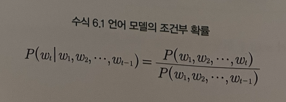
    - 언어 모델에서 조건부 확률을 계산하기 위해 이전에 등장한 단어 시퀀스(W_1, W_2,...W_t-1)를 기반으로 다음 단어 (W_t)의 확률을 계산, 위 이미지의 수식에 조건부 확률의 연쇄법칙(Chain rule for conditional probability) 을 적용한다면 아래 이미지의 수식과 같다.
    - 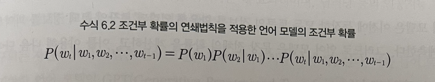
    - 언어 모델에서 조건부 확률은 연쇄법식을 이용해 계산됨, 조건부 확률의 얀쇄벅칙은 하나의 사건이 일어날 확률을 다른 사건들의 조건부 확률을 이용해 계산하는 방식으로 이전 단어들의 시퀀스가 주어졌을 때, 다음에 등장하는 단어의 확률을 이전 단어들의 조건부 확률을 이용해 계산, 따라서 언어 모델에서 조건부 확률은 위 수식과 같이 표현, 문장 전체의 확률은 첫 번째 단어의 확률 P(W_1)과 각 단어가 이전 단어들의 조건부 확률에 따라 발생할 확률의 곱으로 나타낼 수 있음, 이를 통해 언어 모델은 문장 전체의 확률을 계산하고, 그것을 이용해 다음 단어를 예측
    - "안녕하세요" 다음에 등장할 수 있는 문장을 조건부 확률의 연쇄법칙 방법으로 시각화 하면 아래 이미지와 같음
    - 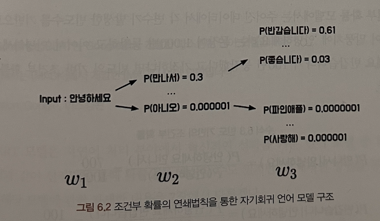
    - 자기회귀 언어 모델에서는 각 시점에서 다으에 올 토큰을 예측하는 것이 중요, 이를 위해 입력 토큰 W_1을 바탕으로 모델은 다음 토큰 W_2가 등장할 확률 P(W_2 | W_1) 을 예측함, 그 다음 모델의 출력값 W_2가 다시 입력값이 되어, 모델은 확률 P(W_3 | W_1, W_2)를 예측, 이러한 방식으로 모델의 출력값이 모델의 입력값으로 사용되는 특징 때문에 자기회귀라는 이름이 붙음, 자기회귀 언어 모델은 시점별로 다음에 올 토큰을 예측하는 것이므로, 토큰 분류 문제로 정의할 수 있음
    - 자기회귀 모델은 이전에 등장한 모든 토큰의 정보를 활용해 입력된 문장의 문맥 정보를 파악하고 다음 토큰을 예측, 그러므로 언어 모델은 문장 전체의 확률을 계산하고, 이를 이용해 다음 단어를 예측

- 통계적 언어 모델
    - 통계적 언어 모델(Statistical Language Model)은 언어의 통계적 구조를 이용해 문장이나 단어의 시퀀스를 생성하거나 분석, 시퀀스에 대한 확률 분포를 추정해 문장의 문맥을 파악해 다음에 등장할 단어의 확률을 예측
    - 일반적으로 통계적 언어 모델은 마르코프 체인(Markov Chain)을 이용해 구현, 마르코프 체인은 빈도 기반의 조건부 확률 모델 중 하나로 이전 상태와 현재 상태 간의 전이 확률을 이용해 다음 상태를 예측
    - 빈도 기반의 조건부 확률 모델에서는 주어진 데이터에서 각 변수가 발생한 빈도수를 기반으로 확률을 계샨, 예를 들어 말뭉치에 "안녕하세요" 라는 문장이 1,000번 등장하고 이어서 "안녕하세요 만나서" 가 700번, "안녕하세요 반갑습니다" 가 100번 등장했다고 가정한다면 빈도의 기반 조건부 확률 수식은 아래 이미지의 수식과 같음
    - 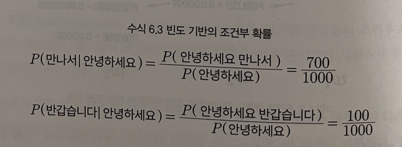
    - 이 방법은 단어의 순서와 빈도에만 기초해 문장의 확률을 예측하므로 문맥을 제대로 파악하지 못하면 불완전하거나 부적절한 결과를 생성할 수 있음, 또한 한 번도 등장한 적이 없는 단어나 문장에 대해서는 정확한 확률을 예측하기가 어려움, 이렇게 관측한 적이 없는 데이터를 예측하지 못하는 문제를 데이터 희소성(Data sparsity) 문재 러고 함, 하지만 통계적 온어 모델은 기존에 학습한 텍스트 데이터에서 패턴을 찾아 확률 분포를 생성하므로, 이를 이용하여 새로운 문장을 생성할 수 있으며, 다양한 종류의 텍스트 데이터를 학습 가능
    - 통계적 언어 모델은 대규모 자연어 데이터를 처리하는 데 효과적이며, 딥러닐 등의 인공지는 기술이 발전하면서 더욱 강력한 모델을 구현할 수 있게 됨
    - 자연어 처리 기법은 언어 모델을 활용해 가중치를 사전 학습, 예를 들어 트랜스포머 모델에 기반한 언어 모델인 GPT(Generative Pre-trained Transformer) 나 BRRT(Bidirectional Encore Representations from Transformers) 는 아래와 같은 문장 생성 기법을 이용해 모델을 사전 학습
        - GPT
            - Raw Sentence: GPT는 OpenAI에서 개발한 인과적 언어 모델
            - Input: GPT는 OpenAI에서 개발한
            - Prediction-1: 인과적
            - Prediction-2: 언어 모델입니다.
        - BERT
            - Raw Sentence: BERT는 Google에서 개발한 마스킹된 언어 모델입니다.
            - Input: BERT는 [MASK]에서 개발한 [MASK] 언어 모델입니다.
            - Prediction: Google, 마스킹된

    - GPT나 BERT 모델은 자연어 처리 분야에서 혁신적인 성과를 거둔 언어 모델 중 하나, GPT와 BERT 모델과 같ㅇ 신경망을 통해 확률 P를 계산할 수 있지만, 통계적인 방법을 통해 확률을 계산할 수도 있음

N-gram

- 가장 기초적인 통계적 언어 모델, N-gram 모델은 텍스트에서 N개의 연속된 단어 시퀀스를 하나의 단위로 취급하여 특정 단어 시퀀스가 등장할 확률을 추정
- N-gram 모델은 입력 텍스트를 하나의 토큰 단위로 분석하지 않고 N개의 토큰을 묶어서 분석함, 이 때 연속된 N개의 단어를 하나의 단위로 취급하여 추론하는 모델, N이 1일때는 유니그램(Unigram), N이 2일때는 바이그램(Bigram), N이 3일때는 트라이그램(Trigram)으로 부름
- N이 4 이상이면 N-gram이라고 부름, 아래 그림은 입력 문장을 유니그램, 바이그램, 트라이그램으로 분할한 예시를 보여줌
- 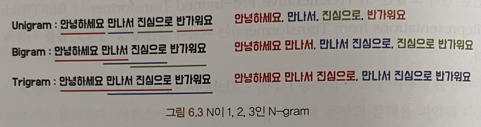
- N-gram 언어 모델은 모튼 토큰을 하용하지 않고 N-1개의 토큰만을 고려해 확률을 계산, 따라서 각 N-gram 언어모델에서 t번째 토큰의 조건부 확률을 계산하는 수식은 아래 그림과 같음
- 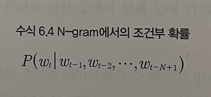

- W_t는 예측하려는 단어, W_t-1 부터 W_t-N+1 까지는 예측에 사용되는 이전 단어들을 의미, 이전 단어들의 개수를 결저아는 N의 값을 조정하여 N-gram 모델의 성능을 조절할 수 있음
- N-gram은 
- 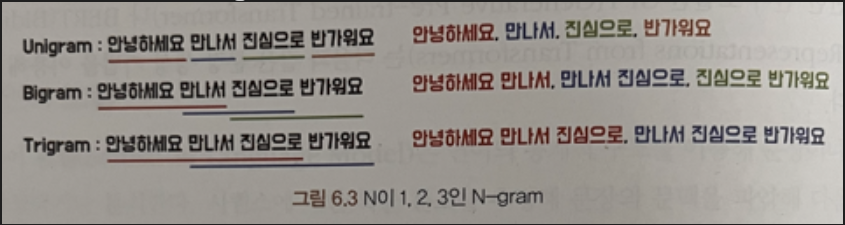 과 
- 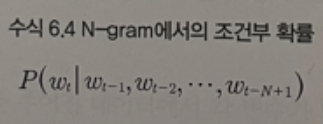 에서 확인할 수 있듯이 간단한 파이썬 코드 또는 NLTK 라이브러리로 구현 가능

In [2]:
# N-gram 구현

import nltk

def ngrams(sentence, n):
    words = sentence.split()
    ngrams = zip(*[words[i:] for i in range(n)])
    return list(ngrams)

sentence = "안녕하세요 만나서 진심으로 반가워요"

unigram = ngrams(sentence, 1)
bigram = ngrams(sentence, 2)
trigram = ngrams(sentence, 3)

print(unigram)
print(bigram)
print(trigram)

unigram = nltk.ngrams(sentence.split(), 1)
bigram = nltk.ngrams(sentence.split(), 2)
trigram = nltk.ngrams(sentence.split(), 3)

print(list(unigram))
print(list(bigram))
print(list(trigram))

[('안녕하세요',), ('만나서',), ('진심으로',), ('반가워요',)]
[('안녕하세요', '만나서'), ('만나서', '진심으로'), ('진심으로', '반가워요')]
[('안녕하세요', '만나서', '진심으로'), ('만나서', '진심으로', '반가워요')]
[('안녕하세요',), ('만나서',), ('진심으로',), ('반가워요',)]
[('안녕하세요', '만나서'), ('만나서', '진심으로'), ('진심으로', '반가워요')]
[('안녕하세요', '만나서', '진심으로'), ('만나서', '진심으로', '반가워요')]


- N-gram은 작은 큐모의 데이터셋에서 연속된 문자열 패턴을 분석하는 데 큰 효과를 보임, 또한 관용적 표현 분석에도 활용, 예를 들어 "입이 무겁다" 라는 표현은 "비밀을 잘 지킨다" 라는 뜻, 그러므로 자주 등장하는 연속된 단어나 구를 추출하고, 이를 분석함으로써 관용적 표현을 파악할 수 있음
- N-gram은 시퀀스에서 연속된 n개의 단어를 추출하므로 단어의 순서가 중요한 자연어 처리 작업 및 문자열 패턴 분석에 활용

TF-IDF

- TF-IDF(Term Frequency-Inverse Document Frequency)란 텍스트 문서에서 특정 단어의 중요도를 계산하는 방법, 문서 내에서 단어의 중요도를 평가하는데 사용되는 통계적인 가중치를 의미, 즉 TF-IDF BoW(Bag-of-Words)에 가중치를 부여하는 방법
- BoW는 문서나 문장을 단어의 집합으로 표현하는 방법으로, 문서나 문장에 등장하는 단어의 중복을 허용해 빈도를 기록, 원-핫 인코딩은 단어의 등장 여부를 판별해 0과 1로 표현하는 방식, BoW는 등장 빈도를 고려해 표현, 예를 들어, ["That movie is famous movie", "I like that actor", "I don't like that actor"] 말뭉치를 Bow 로 벡터와 하면 아래 표와 같음

    | | I | like | this | movie | don't | famous | is |
    |--|--|--|--|--|--|--|--|
    | This movie is famous movie | 0 | 0 | 1 | 2 | 0 | 1 | 1 |
    | I like this movie | 1 | 1 | 1 | 1 | 0 | 0 | 0 |
    | I don't like movie | 1 | 1 | 1 | 1 | 1 | 0 | 0 |

- BoW를 이용해 벡터화 하는 경우 모든 단어는 동일할 가중치를 가짐, BoW 벡터를 활용해 영화 리뷰의 긍/부정 분류 모델을 만든다고 가정한다면 높은 성능을 얻기는 어려움
- "I like this movie" 와 "I don't like this movie" 문장은 "don't" 라는 단어가 문장 분류에 결정적인 역할을 함, 하지만 "don't"라는 단어는 자주 등장하지 않으므로 토큰화나 분류 모델 진행 시 해당 데이터가 무시될 수 있음

- 단어 빈도
    - 단어 빈도(Term Frequency, TF)란 문서 내에서 특장 단어의 빈도수를 나타내는 값, 예를 들어 3개의 문서에서 "movie"라는 단어가 4번 등장한다면 해당 단어의 TF 값은 4가 됨, 이를 수식으로 나타내면 아래와 같음
    - 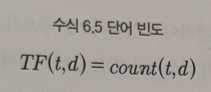
    - 앞선 BoW 벡터 표현 방법과 같이 문서내에서 단어가 등장한 빈도수를 계산하며, 해당 단어의 상대적인 중요도를 측정하는 데 사용
    - TF 값이 높을 수록 해당 단어가 특정 문서에서 중요한 역할을 한다고 생각할 수 있지만, 단어 자체가 특정 문서 내에서 자주 사용되는 단어이므로 전문 용어나 관용어로 간주할 수 있음.
    - TF는 단순히 단어의 등장 빈도수를 계산하기 때문에 문서의 길이가 길어질수록 해당 단어의 TF 값도 높아질수 있음

- 문서 빈도
    - 문서 빈도(Document Frequency, DF)란 한 단어가 얼마나 많은 문서에 나타나는지를 의미, 특정 단어가 많은 문서에 나타나면 문서 집합에서 단어가 나타나는 횟수를 계산, 그러므로 3개의 문서에서 "movie"라는 단어가 4번 등장한다면 해당 단어의 DF 값은 3이 됨, 문서 빈도수를 수식으로 표현한다면 아래 이미지의 수식과 같음
    - 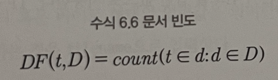
    
    - DF는 단어가 몇 개의 문서에서 등장하는 지 계산, DF 값이 높으면 특정 단어가 많은 문서에서 등장한다고 볼 수 있음, 그 단어는 일반적으로 널리 사용되며, 중요도가 낮을 수 있음
    - 반대로 DF값이 낮다면 특정 단어가 적은 수의 문서에만 등장한다는 뜻, 그러므로 특정한 문맥에서만 사용되는 단어일 가능성이 있으며, 중요도가 높을 수 있음

- 역문서 빈도
    - 역문서 빈도(Inverse Document Frequency, IDF)란 전체 문서 수를 문서 빈도로 나눈 다음에 로그를 취한 값, 이는 문서 내에서 특정 단어가 얼마나 중요한지를 나타냄
    - 문서 빈도가 높을 수록 해당 단어가 일반적이로 상대적으로 즁요하지 않다는 의미, 그러므로 문서 빈도의 역수를 취하면 단어의 빈도수가 적을 수록 IDF 값이 커지게 보정하는 역할을 함, 이를 통해 문서에서 특정 단어의 등장 횟수가 적으면 IDF는 상대적으로 커짐, IDF를 수식으로 표현하면 아래 이미지의 식과 같음
    - 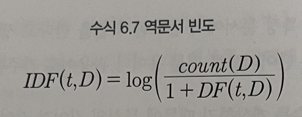
    - IDF는 분모의 DF 값에 1을 더한 값을 사영, 특정 단어가 한 번도 등장하지 않는 다면 분모가 0이 되는 경우가 발생, 그러므로 1과 같은 작은 값을 더해 분모가 0이 도는 결과를 방지, 추가로 IDF는 로그를 취함, 전체 문서 수를 문서 빈도로 나눈 값을 사용한다면 너무 큰 값이 나올 수 있음, 10,000개의 문서에서 특정한 단어가 1번만 등장한다면 IDF 값은 5,000이 됨, 이러한 문제점을 방지하고자 로그를 취해 정교한 가중치를 얻음

- TF-IDF
    - TF-IDF는 앞선 문서 빈도롸 역문서 빈도를 곱한 값으로 사용, TF-IDF를 수식으로 표현하면 아래 이미지의 식과 같음
    - 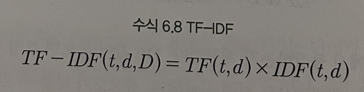

- 문서 내에 단어가 자주 등장하지만, 전체 문서 내에 해당 단어가 적게 등장한다면 TF-IDF 값은 커짐, 그러므로 전체 문서에서 자주 등장할 확률이 높은 관사나 관용어 등의 가중치는 낮아짐
- 파이썬의 사이킷런(Scikit-learn) 라이브러리를 활용해 TF-IDF를 계산, 사이킷런 라이브러리는 파이썬의 대표적인 머신러닝 라이브러리로 머신러닝에 필요한 전처리, 모델 파이프라인, 모델 검증등에 필요한 전반적인 모듈을 제공

In [4]:
!pip install scikit-learn

In [7]:
import sklearn
from sklearn import feature_extraction

tfidf_vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(
    input="content",
    encoding="utf-8",
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 1),
    max_df=1.0,
    min_df=1,
    vocabulary=None,
    smooth_idf=True
)

- TF-IDF(TfidfVectorizer) 클래스의 입력값(input)은 입력될 데이터의 형태를 의미, 기본값으로 설정된 content는 문자열 데이터 혹은 바이트 형태의 입력값을 의미, 파일 객체를 사용한다면 file로 입력하며, 파일 경로를 사용하는 경우 filename으로 입력
- 인코딩(encoding)은 바이트 혹은 파일을 입력값으로 받을 경우 사용할 텍스트 인코딩 값을 의미
- 소문자 변환(lowercase)은 입력받은 데이터를 소문자로 변환할지 여부를 말함, 참값으로 설정하면 모든 입력 텍스트를 소문자로 변환
- 불용어(stop_words)는 분석에 도움이 되지 않는 의미 없는 단어를 의미하며, 입력받은 단어들은 단어 사전에 추가되지 않음
- N-gram 범위(ngram_range)는 사용할 N-gram의 범위를 의미, (최소값, 최대값) 형태로 입력하며 (1, 1)은 유니그램, (1, 2)는 유니그램과 바이그램을 사용한다는 것을 의미
- 최대값 문서 빈도(max_df)는 전체 문서 중 일정 횟수 이상 등장한 단어는 불용어로 처리, 정수 입력하면 해당 등장 횟수를 초과해 등장하는 단어를 불용어로 처리하며, 1 이하의 실수를 입력하면 해당 비율을 초과해 등장하는 단어를 불용어 처리
- 최소값 문서 빈도(min_df)는 전체 문서 중 일정 횟수 미만으로 등장한 단어를 불용어 처리한다는 뜻으로 최대값 문서 빈도와 동일한 패턴으로 입력 가능
- 단어 사전(vocabulary)은 미리 구축한 단어사전이 있다면 해당 단어 사전을 사용한다. 만약 입력하지 않으면 TF-IDF 학습 시 자동으로 구축
- IDF 분모처리(smooth_idf)는 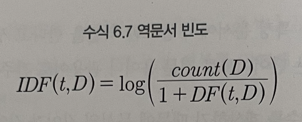의 수식과 같이 IDF 계산 시 분모에 1을 더함

In [8]:
# ["That movie is famous movie", "I like that actor", "I don't like that actor"] 를 벡터화

from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "That movie is famous movie", 
    "I like that actor", 
    "I don't like that actor"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(corpus)
tfidf_matrix = tfidf_vectorizer.transform(corpus)

print(tfidf_matrix.toarray())
print(tfidf_vectorizer.vocabulary_)

[[0.         0.         0.39687454 0.39687454 0.         0.79374908
  0.2344005 ]
 [0.61980538 0.         0.         0.         0.61980538 0.
  0.48133417]
 [0.4804584  0.63174505 0.         0.         0.4804584  0.
  0.37311881]]
{'that': 6, 'movie': 5, 'is': 3, 'famous': 2, 'like': 4, 'actor': 0, 'don': 1}


- 사이킷런의 TF-IDF 클래스는 fit 메서드를 통해 학습해야 데이터의 변환 또는 추론이 가능, TF-IDF 클래스를 통해 tfidf_vectorizer 객체를 불러오고, fit 메서드를 통해 준비된 말뭉치를 학습, 객체의 학습이 완료되면 transform 메서드를 이용해 데이터 변환을 수행할 수 있음, 또는 fit_transform 메서드를 통해 학습과 변환을 동시에 수행 가능
- toarray 메서드는 TF-IDF를 넘파이 배열로 변환하며, (문서 수) * (단어 수)의 형태를 가짐, 각 행은 하나의 문서에 해당하며, 각 열은 단어를 의미
- vocabulary_ 속성은 TF_IDF에 사용된 단어 사전을 의미, 딕셔너리의 키는 고유한 단어를 의미하며, 값은 해당 단어에 대한 색인 값을 의미
- TF-IDF에서 점수가 가장 높은 값을 세개만 추려 색인으로 정리하면 [[2, 3, 5], [0, 4, 6], [0, 1, 4]] 가 됨, 이를 단어 사전과 매핑하면 [[famous, is, movie], [actor, like, that], [actor, don, like]]가 됨
- 이를 통해 문서마다 중요한 단어만 추출할 수 있으며, 벡터값을 활용해 문서 내 핵심 단어를 추출할 수 있음, 하지만 출력 결과에서 확이할 수 있듯이 빈도 기반 벡터화는 문장의 순서나 문맥을 고려하지 않음, 그러므로 문장 생성과 같이 순서가 중요한 작업에는 부적합, 또한 벡터가 해당 문서 내에 중요도를 의미할 뿐, 벡터가 단어의 의미를 담고 있지는 않음
- 예를 들어, ["나느 바나나를 먹었다", "그녀가 과일을 섭취한다", "고양이는 야옹 운다"]를 벡터화한다면 "나는 바나나를 먹었다" 와 "그녀가 과일을 섭취한다" 가 "고영이는 야옹 운다" 보다 더 가까운 의미를 가지고 있디만 세 문장 간의 유사도는 동일함